# 1 Nonlinear Oscillator Non-Markovian Sine-Drive Example

This example runs a delayed-feedback simulation for one nonlinear harmonic oscillator driven by a sinusoidal classical field.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import time as t

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import wqedmps as qmps


def _delay_window_total(per_bin: np.ndarray, delay_steps: int) -> np.ndarray:
    """Accumulate the population currently stored over one delay window."""
    values = np.asarray(per_bin, dtype=float)
    if delay_steps <= 0:
        return np.zeros_like(values)

    csum = np.cumsum(values)
    total = csum.copy()
    if len(values) > delay_steps:
        total[delay_steps:] = csum[delay_steps:] - csum[:-delay_steps]
    return total


def run_feedback_nho_sine_drive_example(
    d_sys: int = 6,
    U: float = 0,
    show: bool = True,
) -> tuple[qmps.InputParams, qmps.Bins, dict[str, np.ndarray | float]]:
    """Run a 1-NHO delayed-feedback example with a sinusoidal drive."""
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=10.0,
        tau=2.0,
        d_sys_total=np.array([d_sys]),
        d_t_total=np.array([2]),
        gamma_l=0.5,
        gamma_r=0.5,
        U=U,
        phase=0,
        bond_max=24,
        atol=1e-12,
    )

    drive_times = np.arange(params.steps) * params.delta_t
    drive = 1.2 * np.sin(1.6 * drive_times)

    initial_system = qmps.wg_ground(params.d_sys)
    initial_field = qmps.vacuum(params.tmax, params)

    start_time = t.time()
    hamiltonian = qmps.hamiltonian_1nho_feedback(params, omega=drive, delta=0.0)
    bins = qmps.t_evol_nmar(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    times = np.asarray(bins.times, dtype=float)
    nho_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, qmps.num_op(params.d_sys)),
        dtype=float,
    )
    loop_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.loop_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    feedback_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.output_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    input_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.input_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )

    delay_total_pop = _delay_window_total(loop_bin_pop, params.delay_steps)
    emitted_output = np.cumsum(feedback_bin_pop)
    runtime = float(t.time() - start_time)
    print("--- %s seconds ---" % runtime)

    observables = {
        "times": times,
        "drive_times": drive_times,
        "drive": drive,
        "nho_pop": nho_pop,
        "loop_bin_pop": loop_bin_pop,
        "feedback_bin_pop": feedback_bin_pop,
        "input_bin_pop": input_bin_pop,
        "delay_total_pop": delay_total_pop,
        "emitted_output": emitted_output,
        "runtime": runtime,
    }

    if show:
        fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

        axes[0].plot(
            drive_times, drive, lw=2.5, label=r"$\Omega(t) = \Omega_0 \sin(\nu t)$"
        )
        axes[0].set_ylabel("Drive")
        axes[0].set_title("1 nonlinear oscillator with delayed feedback")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(times, nho_pop, lw=2.5, label="Oscillator occupation")
        axes[1].plot(times, delay_total_pop, lw=2.5, label="Population in delay line")
        axes[1].plot(times, emitted_output, lw=2.5, label="Cumulative emitted output")
        axes[1].set_ylabel("Population")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        axes[2].plot(times, loop_bin_pop, lw=2.5, label="Loop-bin expectation")
        axes[2].plot(times, feedback_bin_pop, lw=2.5, label="Feedback-bin expectation")
        axes[2].plot(times, input_bin_pop, lw=2.5, label="Input-bin expectation")
        axes[2].set_xlabel("Time")
        axes[2].set_ylabel("Local bin population")
        axes[2].legend()
        axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return params, bins, observables


# run_feedback_nho_sine_drive_example()


--- 1.9300036430358887 seconds ---
--- 3.1386852264404297 seconds ---


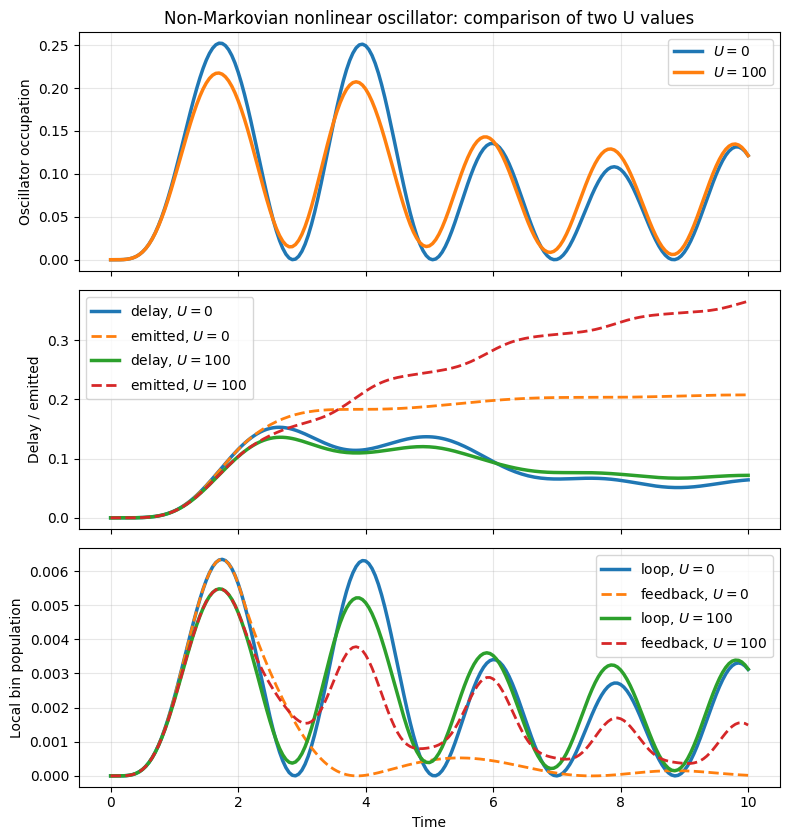

In [ ]:
compare_u_values = [0.0, 100.0]
compare_results = {}

for U_value in compare_u_values:
    _, _, compare_results[U_value] = run_feedback_nho_sine_drive_example(
        U=U_value, show=False, d_sys=10
    )

times = compare_results[compare_u_values[0]]["times"]

fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.5), sharex=True)

for U_value in compare_u_values:
    result = compare_results[U_value]
    axes[0].plot(times, result["nho_pop"], lw=2.5, label=rf"$U={U_value:g}$")
axes[0].set_ylabel("Oscillator occupation")
axes[0].set_title("Non-Markovian nonlinear oscillator: comparison of two U values")
axes[0].legend()
axes[0].grid(alpha=0.3)

for U_value in compare_u_values:
    result = compare_results[U_value]
    axes[1].plot(
        times, result["delay_total_pop"], lw=2.5, label=rf"delay, $U={U_value:g}$"
    )
    axes[1].plot(
        times,
        result["emitted_output"],
        "--",
        lw=2.0,
        label=rf"emitted, $U={U_value:g}$",
    )
axes[1].set_ylabel("Delay / emitted")
axes[1].legend()
axes[1].grid(alpha=0.3)

for U_value in compare_u_values:
    result = compare_results[U_value]
    axes[2].plot(times, result["loop_bin_pop"], lw=2.5, label=rf"loop, $U={U_value:g}$")
    axes[2].plot(
        times,
        result["feedback_bin_pop"],
        "--",
        lw=2.0,
        label=rf"feedback, $U={U_value:g}$",
    )
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Local bin population")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
